In [ ]:
from dota2_predictor.data_service.build_db import *
from dota2_predictor.data_service.format_data import *
from dota2_predictor.models.logistic_regression import LGModel
import time
import traceback
from sklearn.model_selection import train_test_split
from sklearn.metrics import zero_one_loss
from sklearn.preprocessing import StandardScaler


In [2]:
"""
Code for retrieving data from dota2 api
"""

# while True:
#     try:
#         print("get matches")
        
#         ret = save_matches_list(get_matches())
#         print(f"upserted:{ret.upserted_count}")
#         time.sleep(100)
#         print("end sleep")
#     except Exception as e:
#         print(traceback.format_exc())
#         raise e

'\nCode for retrieving data from dota2 api\n'

In [5]:
#ATTEMPT 1 and 2

"""
First atttempt used very simple features, just appending the arrays of hero selection of both teams,
values were normalized

Maximum accuracy 0.48-0.62, basically random no learning
0-1 loss showed no improvement when plotted confirming that the model was making basically random choices

These values non normalized
Second attempt used one hot encoding, array of length 2* total number of heroes, 0 where heroes not chosen 1 where chosen

Accuracy was reliably 0.62 plotting 0-1 loss and log loss significant improvement in 0-1 loss and logloss

These values non normalized
Third attempt group by hero role to have better representation in features, feature structure is single array split into sections
    i.e:
        feature = [team1 feature]+team2[feature]
        [team1 feature] = [heroes of attribute1]+[heroes of attribute2]+[heroes of attribute3]+[heroes of attribute4]
        [team2 feature] = [heroes of attribute1]+[heroes of attribute2]+[heroes of attribute3]+[heroes of attribute4]
        still using one hot encoding for the heroes

Fourth attemt repeat attempt 3 but add featured for each team correscponding to hero roles
these values are normalized


"""

features,labels = get_saved_matches()
features = extract_features(features)

features_train, features_val, labels_train, labels_val = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)
normalizer = StandardScaler(copy=False)
features_train_n = normalizer.fit_transform(features_train)
features_val_n = normalizer.transform(features_val)

model = LGModel()
loglosses,loss_01 = model.logistic_regression(features_train,labels_train,alpha=0.001,epochs=5000,batch_size=200)


print(zero_one_loss(labels_val,model.predict(features_val)))

cur_epoch = 0
cur_epoch = 1
cur_epoch = 2
cur_epoch = 3
cur_epoch = 4
cur_epoch = 5
cur_epoch = 6
cur_epoch = 7
cur_epoch = 8
cur_epoch = 9
cur_epoch = 10
cur_epoch = 11
cur_epoch = 12
cur_epoch = 13
cur_epoch = 14
cur_epoch = 15
cur_epoch = 16
cur_epoch = 17
cur_epoch = 18
cur_epoch = 19
cur_epoch = 20
cur_epoch = 21
cur_epoch = 22
cur_epoch = 23
cur_epoch = 24
cur_epoch = 25
cur_epoch = 26
cur_epoch = 27
cur_epoch = 28
cur_epoch = 29
cur_epoch = 30
cur_epoch = 31
cur_epoch = 32
cur_epoch = 33
cur_epoch = 34
cur_epoch = 35
cur_epoch = 36
cur_epoch = 37
cur_epoch = 38
cur_epoch = 39
cur_epoch = 40
cur_epoch = 41
cur_epoch = 42
cur_epoch = 43
cur_epoch = 44
cur_epoch = 45
cur_epoch = 46
cur_epoch = 47
cur_epoch = 48
cur_epoch = 49
cur_epoch = 50
cur_epoch = 51
cur_epoch = 52
cur_epoch = 53
cur_epoch = 54
cur_epoch = 55
cur_epoch = 56
cur_epoch = 57
cur_epoch = 58
cur_epoch = 59
cur_epoch = 60
cur_epoch = 61
cur_epoch = 62
cur_epoch = 63
cur_epoch = 64
cur_epoch = 65
cur_epoch = 66
cur_e

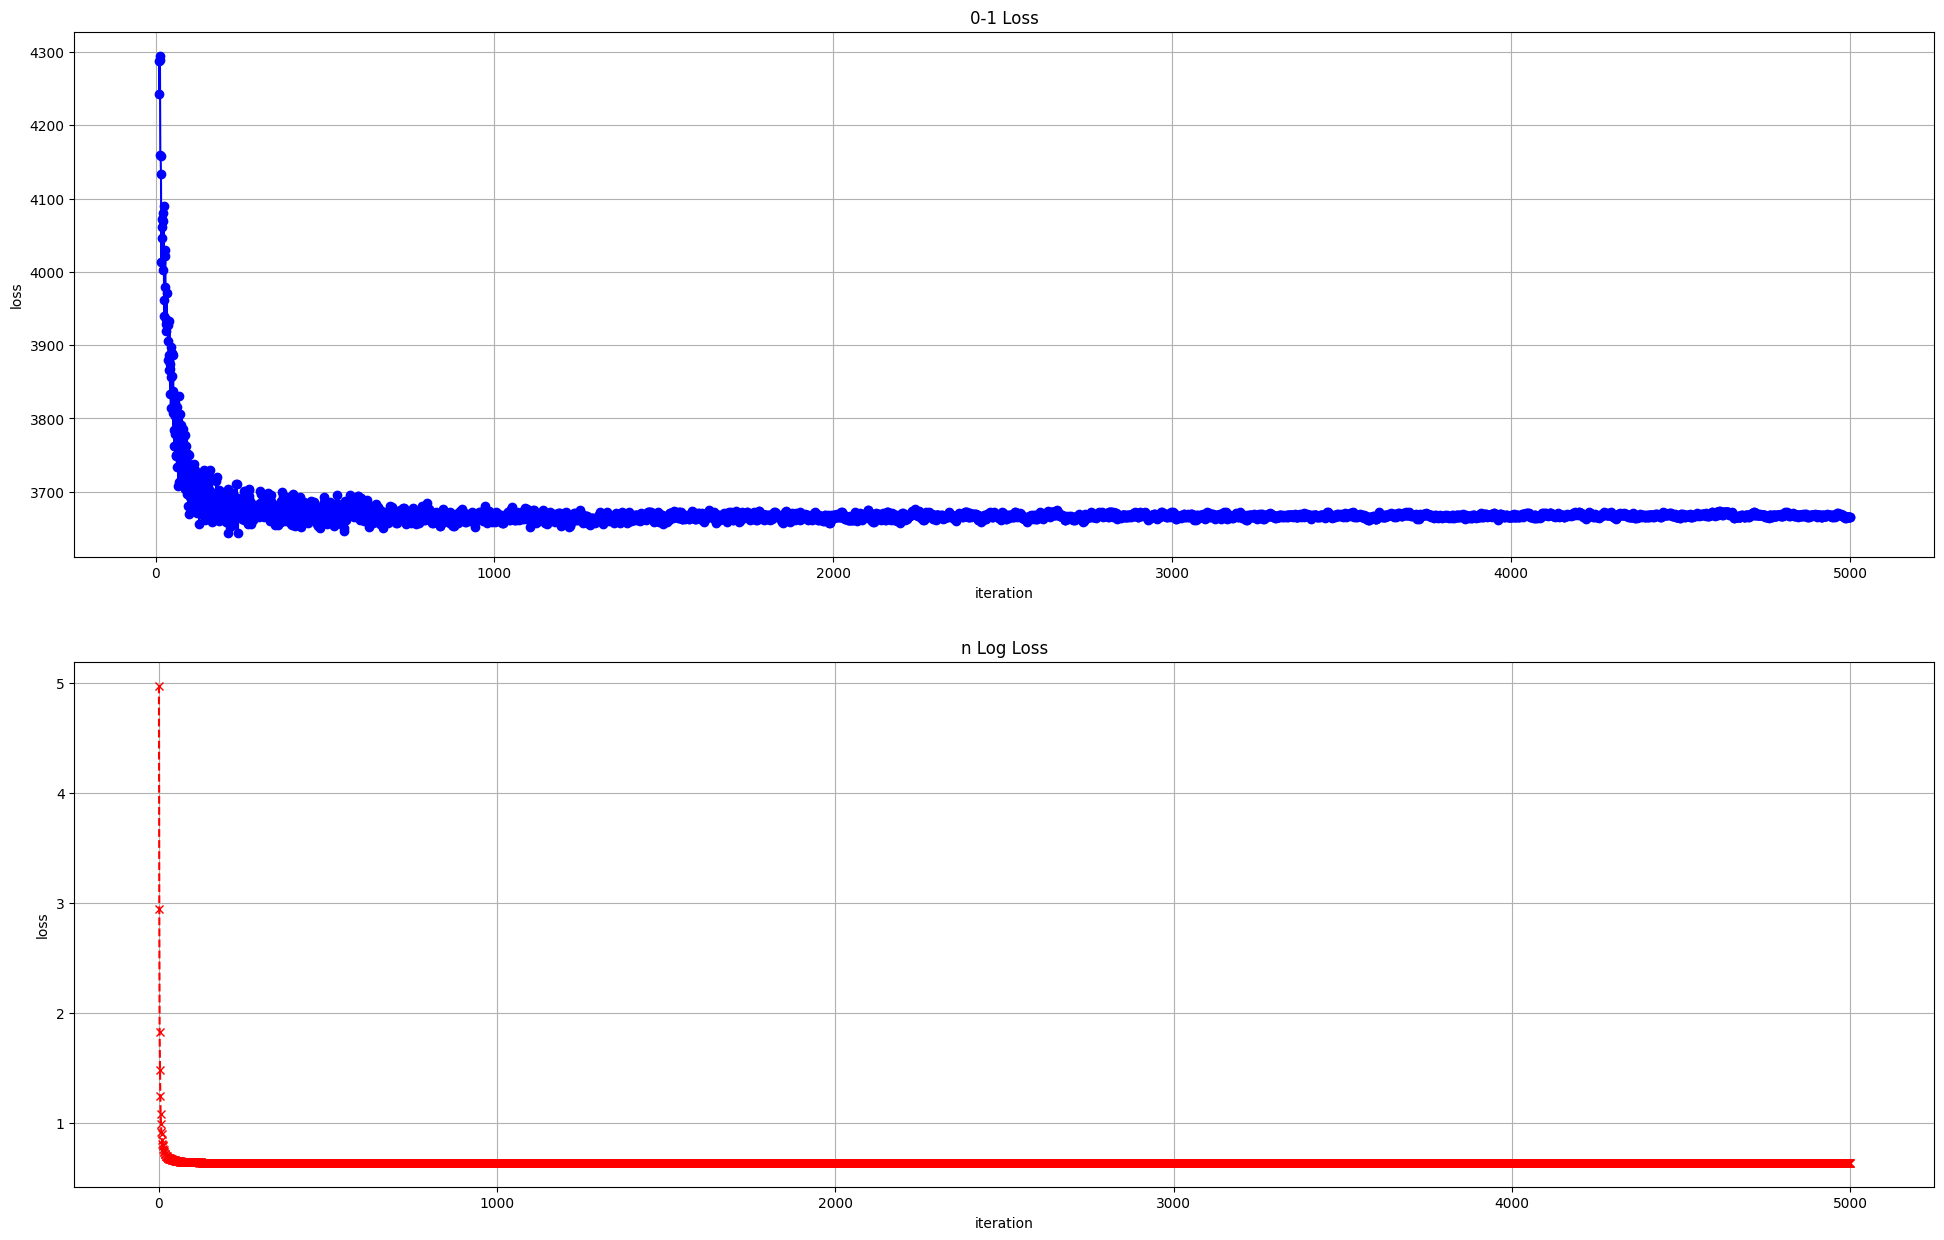

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(24, 15))

ax1.plot(range(10,len(loss_01)), loss_01[10:], label='0-1 loss', color='blue', linestyle='-', marker='o')
ax1.set_xlabel('iteration')
ax1.set_ylabel('loss')
ax1.set_title('0-1 Loss')
ax1.grid(True)

ax2.plot(range(len(loglosses)), loglosses, label='n log loss', color='red', linestyle='--', marker='x')
ax2.set_xlabel('iteration')
ax2.set_ylabel('loss')
ax2.set_title('n Log Loss')
ax2.grid(True)

## Summary of findings for Logistic Regression

* Feature engineering resulted in the greates change in accuracy
* With small dense vector features accuracy was random
* With larger sparse vectors using one hot encoding the accuracy was reliably 60%
* Further feature engineering of the sparse vectors did not see any significant increase in accuracy
* Possible due to non linear relationship between features not able to be captured by the logistic model
* Using Neural Networks possibly the accuracy will improve

### Next Experiment

* Using the same features evaluate the performance of neural networks on the data set 

In [16]:
from dota2_predictor.data_service.build_db import *
from dota2_predictor.data_service.format_data import *
from dota2_predictor.models.logistic_regression import LGModel
import time
import traceback
from sklearn.model_selection import train_test_split
from sklearn.metrics import zero_one_loss
from sklearn.preprocessing import StandardScaler
from dota2_predictor.models.neural_net import NNModel

features,labels = get_saved_matches()
features = extract_features(features)
print(len(features))
labels = 1-labels


features_train, features_val, labels_train, labels_val = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

# normalizer = StandardScaler(copy=False)
# features_train_n = normalizer.fit_transform(features_train)
# features_val_n = normalizer.transform(features_val)

import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=len(features_train[0])//4)
features_train_pca = pca.fit_transform(features_train)
features_val_pca = pca.transform(features_val)


features_train_pca = format_for_torch(features_train_pca)
features_val_pca = format_for_torch(features_val_pca)
labels_train = format_for_torch(labels_train).unsqueeze(1)
labels_val = format_for_torch(labels_val).unsqueeze(1)


model = NNModel(len(features_train_pca[0]))
accuracy,loglosses,loss01,train_accuracy,train_loss = model.train_model(features=features_train_pca,labels=labels_train,test_feature=features_val_pca,test_labels=labels_val,eta=1e-4,epochs=1000,batch_size=200,decay=1e-3,early_stop=100)
print(accuracy)




17710


Epoch 152: 100%|██████████| 71/71 [00:00<00:00, 358.87batch/s, accuracy=0.72, loss=0.715] 


0.7963568568229675


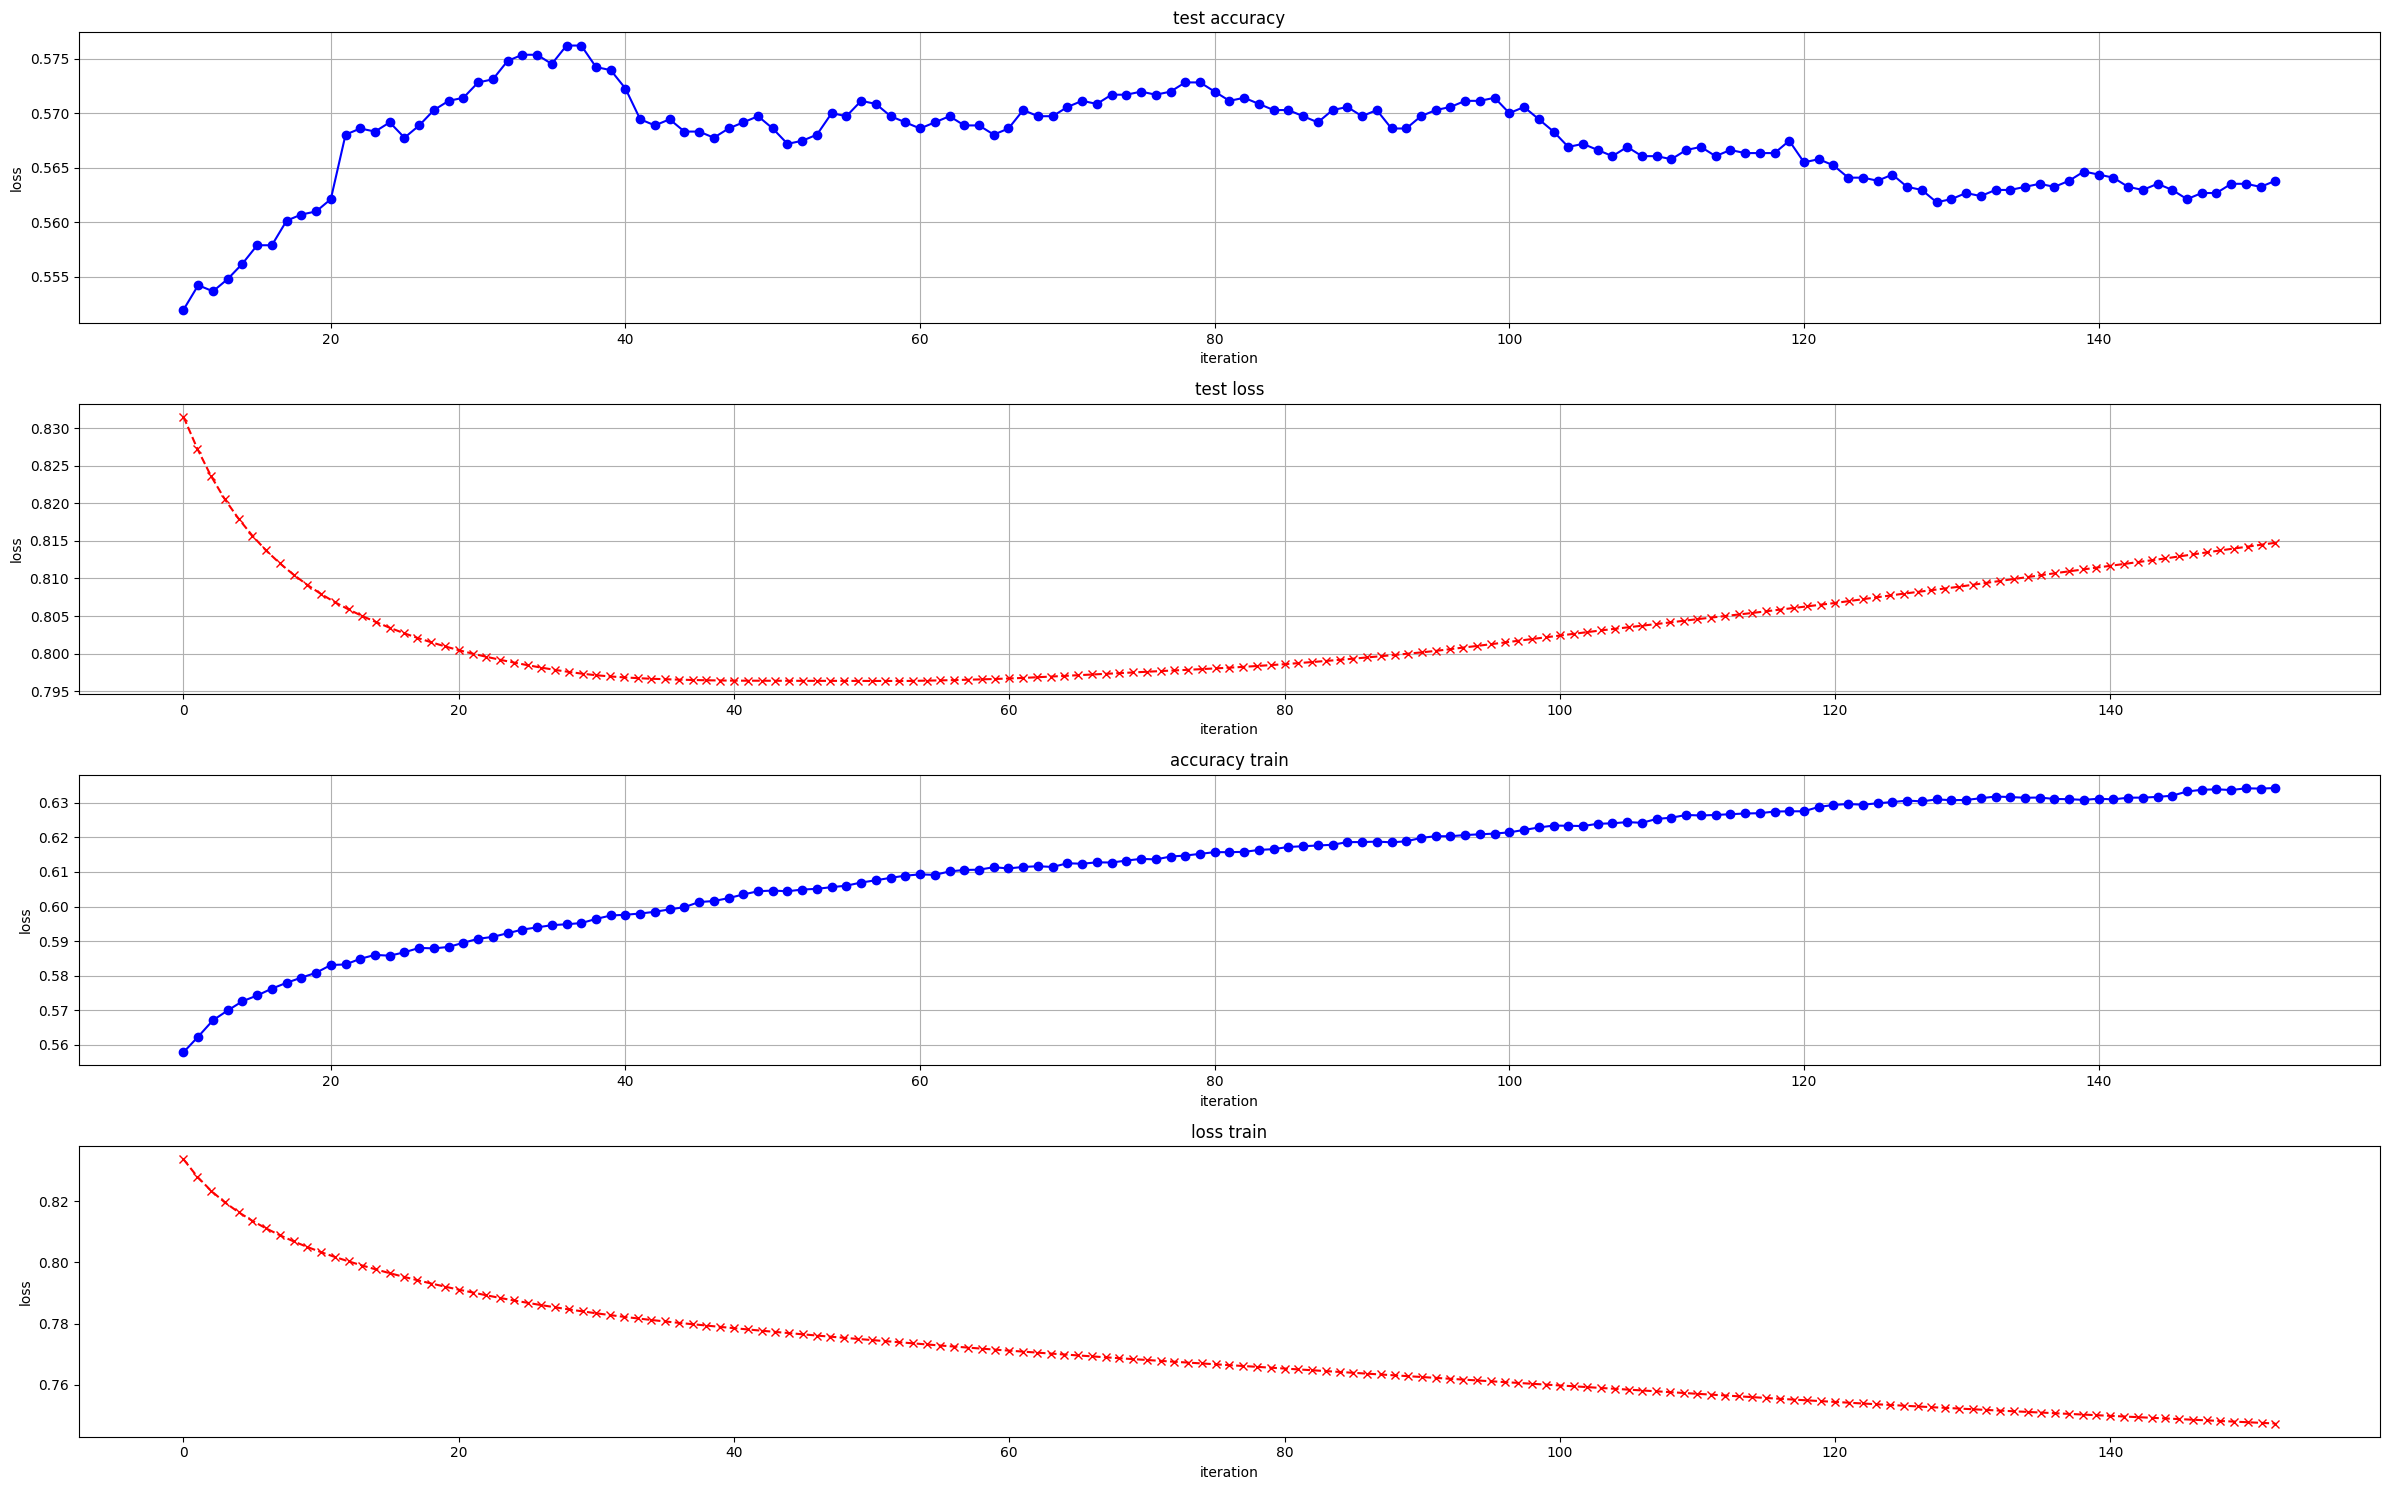

In [19]:
import matplotlib.pyplot as plt
import copy



# loss01_n = [1-i for i in loss01]
loss01_n = loss01
loglosses_n = loglosses
# print(loss01)
# print(loglosses)
fig, (ax1, ax2,ax3,ax4) = plt.subplots(4,1, figsize=(24, 15))

ax1.plot(range(10,len(loss01_n)), loss01_n[10:], label='test accuracy', color='blue', linestyle='-', marker='o')
ax1.set_xlabel('iteration')
ax1.set_ylabel('loss')
ax1.set_title('test accuracy')
ax1.grid(True)

ax2.plot(range(len(loglosses_n)), loglosses_n, label='test loss', color='red', linestyle='--', marker='x')
ax2.set_xlabel('iteration')
ax2.set_ylabel('loss')
ax2.set_title('test loss')
ax2.grid(True)

ax3.plot(range(10,len(train_accuracy)), train_accuracy[10:], label='accuracy train', color='blue', linestyle='-', marker='o')
ax3.set_xlabel('iteration')
ax3.set_ylabel('loss')
ax3.set_title('accuracy train')
ax3.grid(True)

ax4.plot(range(len(train_loss)), train_loss, label='loss train', color='red', linestyle='--', marker='x')
ax4.set_xlabel('iteration')
ax4.set_ylabel('loss')
ax4.set_title('loss train')

plt.tight_layout()
plt.show()

In [21]:
newm = get_matches()

print(len(newm))

entries,labels = [{"radiant_team":entry["radiant_team"],"dire_team":entry["dire_team"]} for entry in newm], np.array([int(data["radiant_win"]) for data in newm]) 
labels = 1-labels
entries = extract_features((entries))

with torch.no_grad():
    # probs = torch.sigmoid(model(format_for_torch(pca.transform(normalizer.transform(entries)))))
    probs = torch.sigmoid(model(format_for_torch(pca.transform(entries))))
f_labels = format_for_torch(labels)

print(probs.round())
count = 0
for i,z in enumerate(probs.round()):
    if z == f_labels[i]:
        count+=1

count = count/len(f_labels)
print(count)
print((probs.round() == f_labels).float().mean())


100
tensor([[0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
  

## Summary of first Neural Network attempt

### Continued using the same features to see how much accuracy is constrained by the model

* PCA reduce feature dimensions to prevent early overfit
* Single hidden layer model of dimensions input dimensions / 2
* Still using binary cross entropy loss
* using normalization per batch 
* using dropout

### Accuracy improved by about 5-10% for a random sample of 100 matches from 60 -> 70 percent.
### Given this result a better neural net may be able to make significant progress

* more hidden layers
* more samples
* tune hyperparameters
* learned embedding features

In [1]:
from dota2_predictor.data_service.build_db import *
from dota2_predictor.data_service.format_data import *
from dota2_predictor.models.logistic_regression import LGModel
import time
import traceback
from sklearn.model_selection import train_test_split
from sklearn.metrics import zero_one_loss
from sklearn.preprocessing import StandardScaler
from dota2_predictor.models.neural_net import NNModel

features,labels = get_saved_matches()
labels = 1-labels



features_train, features_val, labels_train, labels_val = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

hero_table = get_hero_table()
features_train = extract_features(features_train,hero_table)
features_val = extract_features(features_val,hero_table)
labels_train = torch.tensor(labels_train)
labels_val = torch.tensor(labels_val)

print(len(features_train[0])/10)
print(len(labels_train))


10148.0
10148


In [2]:
model = NNModel(hero_dim=8,lin_dim=32)
accuracy,loglosses,loss01,train_accuracy,train_loss = model.train_model(features=features_train,labels=labels_train,test_feature=features_val,test_labels=labels_val,eta=1e-5,epochs=1000,batch_size=100,decay=1e-2,early_stop=50)

Epoch 232: 100%|██████████| 102/102 [00:00<00:00, 133.00batch/s, accuracy=0.688, loss=0.734]


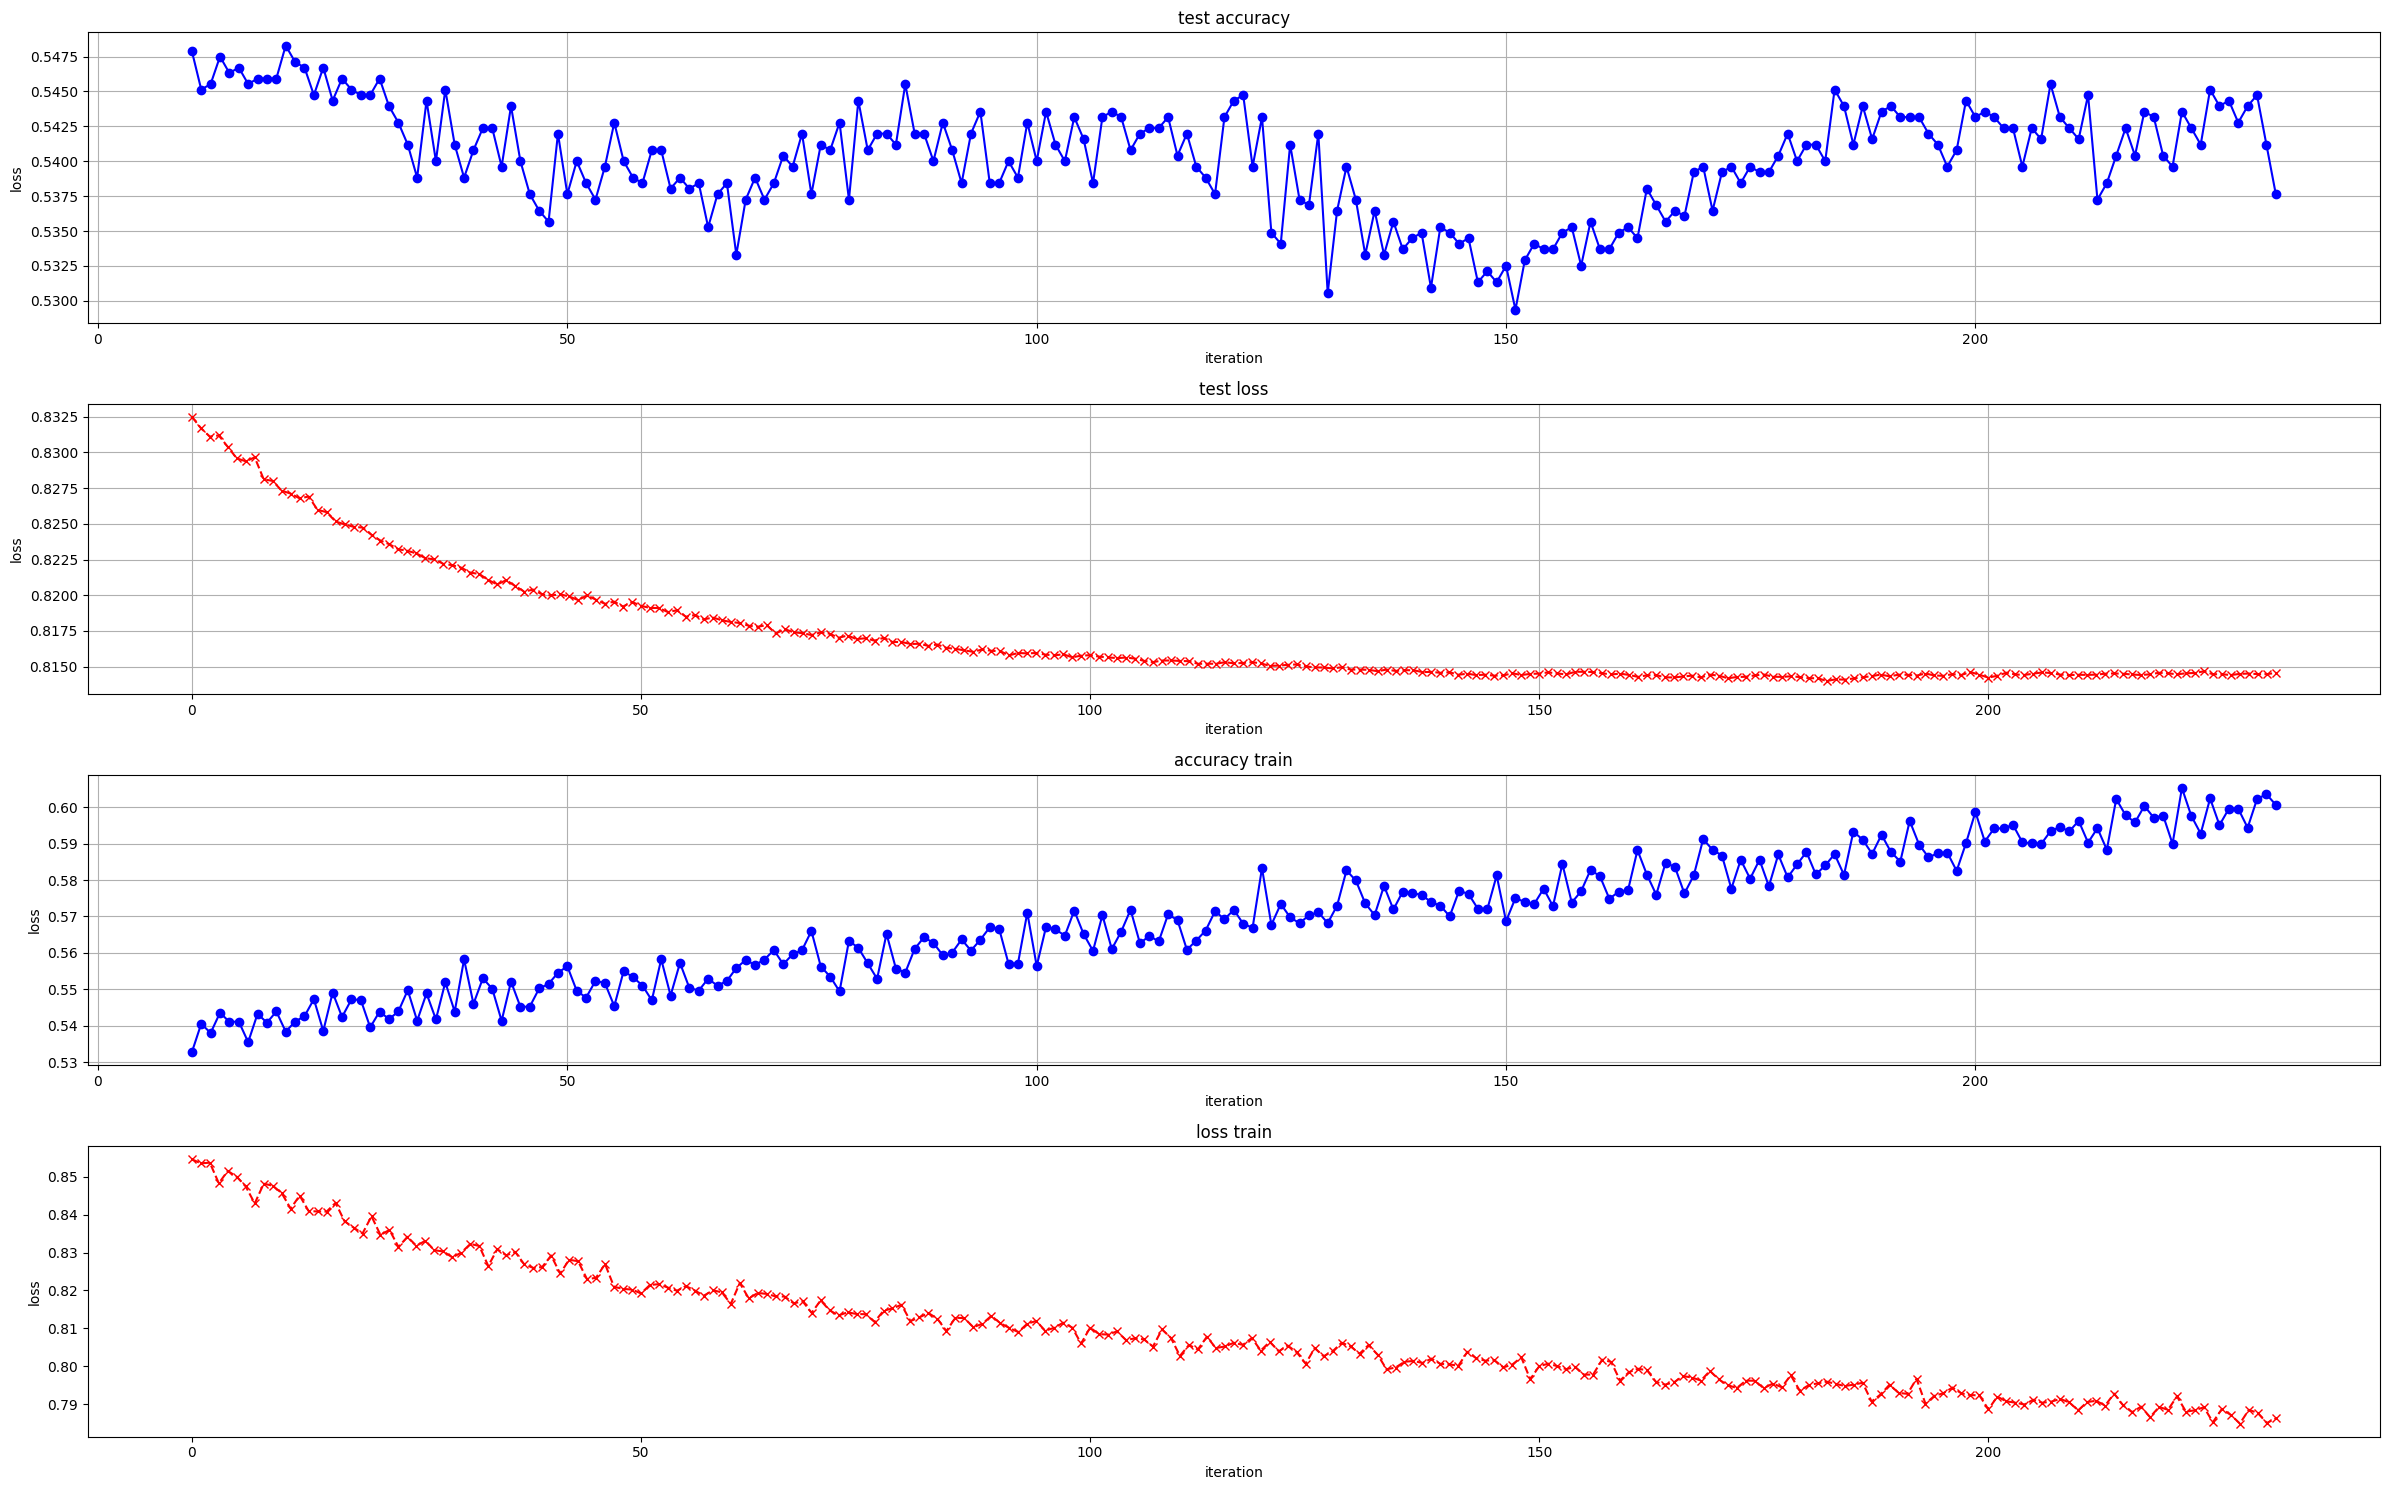

In [3]:
import matplotlib.pyplot as plt
import copy



# loss01_n = [1-i for i in loss01]
loss01_n = loss01
loglosses_n = loglosses
# print(loss01)
# print(loglosses)
fig, (ax1, ax2,ax3,ax4) = plt.subplots(4,1, figsize=(24, 15))

ax1.plot(range(10,len(loss01_n)), loss01_n[10:], label='test accuracy', color='blue', linestyle='-', marker='o')
ax1.set_xlabel('iteration')
ax1.set_ylabel('loss')
ax1.set_title('test accuracy')
ax1.grid(True)

ax2.plot(range(len(loglosses_n)), loglosses_n, label='test loss', color='red', linestyle='--', marker='x')
ax2.set_xlabel('iteration')
ax2.set_ylabel('loss')
ax2.set_title('test loss')
ax2.grid(True)

ax3.plot(range(10,len(train_accuracy)), train_accuracy[10:], label='accuracy train', color='blue', linestyle='-', marker='o')
ax3.set_xlabel('iteration')
ax3.set_ylabel('loss')
ax3.set_title('accuracy train')
ax3.grid(True)

ax4.plot(range(len(train_loss)), train_loss, label='loss train', color='red', linestyle='--', marker='x')
ax4.set_xlabel('iteration')
ax4.set_ylabel('loss')
ax4.set_title('loss train')

plt.tight_layout()
plt.show()

In [4]:
newm = get_matches()

print(len(newm))

entries,labels = [{"radiant_team":entry["radiant_team"],"dire_team":entry["dire_team"]} for entry in newm], np.array([int(data["radiant_win"]) for data in newm]) 
labels = 1-labels
entries = extract_features(entries,hero_table)

with torch.no_grad():
    # probs = torch.sigmoid(model(format_for_torch(pca.transform(normalizer.transform(entries)))))
    probs = torch.sigmoid(model(entries[0],entries[1],entries[2],entries[3]))
f_labels = torch.tensor(labels).float()

count = 0
for i,z in enumerate(probs.round()):
    if z == f_labels[i]:
        count+=1

count = count/len(f_labels)
print(count)
print((probs.round() == f_labels).float().mean())


100
0.51
tensor(0.5100)


In [10]:
from sklearn.linear_model import LogisticRegression


def flatten_features_for_logistic(features):
    primary_attrs, attack_types, roles, float_stats = features
    num_matches = primary_attrs.shape[0] // 10

    # One-hot encode primary attributes and attack types
    primary_onehot = torch.nn.functional.one_hot(primary_attrs, num_classes=4).float()
    attack_onehot = torch.nn.functional.one_hot(attack_types, num_classes=2).float()

    # Concatenate all hero features together
    hero_features = torch.cat([primary_onehot, attack_onehot, roles, float_stats], dim=1)  # (num_matches*10, dim_per_hero)

    # Group heroes per match
    hero_features = hero_features.view(num_matches, 10, -1)  # (num_matches, 10, dim_per_hero)

    # Flatten each match into a single feature vector
    match_features = hero_features.view(num_matches, -1)  # (num_matches, 10 * dim_per_hero)

    # Convert to numpy
    X = match_features.numpy()

    return X

X_train = flatten_features_for_logistic(features_train)
y_train = labels_train.numpy()

X_val = flatten_features_for_logistic(features_val)
y_val = labels_val.numpy()

# Train logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate
print("Train accuracy:", model.score(X_train, y_train))
print("Validation accuracy:", model.score(X_val, y_val))

Train accuracy: 0.62238864800946
Validation accuracy: 0.5999211667323611


NameError: name 'logis' is not defined